In [1]:
import importlib.util
import subprocess
import sys

dependencies = {
    "pandas": "pandas>=2.2,<4",
    "numpy": "numpy>=1.26,<3",
    "matplotlib": "matplotlib>=3.9,<4",
    "seaborn": "seaborn>=0.13,<0.14",
    "missingno": "missingno==0.5.2",
    "IPython": "ipython>=8,<10",
}
missing_packages = [requirement for module, requirement in dependencies.items()
                    if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--root-user-action=ignore", *missing_packages])

from pathlib import Path
from urllib.request import urlopen
import pandas as pd
import numpy as np
import matplotlib
from IPython import get_ipython
from IPython.display import display

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

pd.set_option("display.max_columns", 26)
pd.set_option("display.max_rows", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

FIGURE_DIR = Path("grafik")
FIGURE_DIR.mkdir(exist_ok=True)

def save_figure(fig, filename):
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight", facecolor="white")
    if get_ipython() is not None:
        plt.show()
    plt.close(fig)

DATA_PATH = Path("Automobile_data.csv")
DATA_URL = (
    "https://raw.githubusercontent.com/rushabh-mehta/EDA-on-Automobile-Dataset/"
    "5754646cab131214665a6bcf82e27869edbd120c/Automobile_data.csv"
)

if not DATA_PATH.is_file():
    with urlopen(DATA_URL, timeout=30) as response:
        DATA_PATH.write_bytes(response.read())

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
assert df.shape == (205, 26)
print(f"Ukuran data: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head())

Ukuran data: 205 baris x 26 kolom


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


# 1. Missing value

Tanda `?` diubah menjadi `NaN`. Kolom numerik diisi dengan mean, sedangkan jumlah pintu diisi dengan modus.

In [2]:
display(df.isnull().any().to_frame("terdeteksi_null_sebelum_konversi"))
print("Jumlah penanda '?' yang belum dianggap null:", int(df.eq("?").sum().sum()))

,terdeteksi_null_sebelum_konversi
symboling,False
normalized-losses,False
make,False
fuel-type,False
aspiration,False
num-of-doors,False
body-style,False
drive-wheels,False
engine-location,False
wheel-base,False


Jumlah penanda '?' yang belum dianggap null: 59


In [3]:
df = df.replace("?", np.nan)
missing_before = df.isnull().sum()
expected_missing = {"normalized-losses": 41, "num-of-doors": 2, "bore": 4,
                    "stroke": 4, "horsepower": 2, "peak-rpm": 2, "price": 4}
assert missing_before[missing_before > 0].to_dict() == expected_missing
display(missing_before.to_frame("missing_sebelum_imputasi"))
print("Total missing value:", int(missing_before.sum()))

,missing_sebelum_imputasi
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


Total missing value: 59


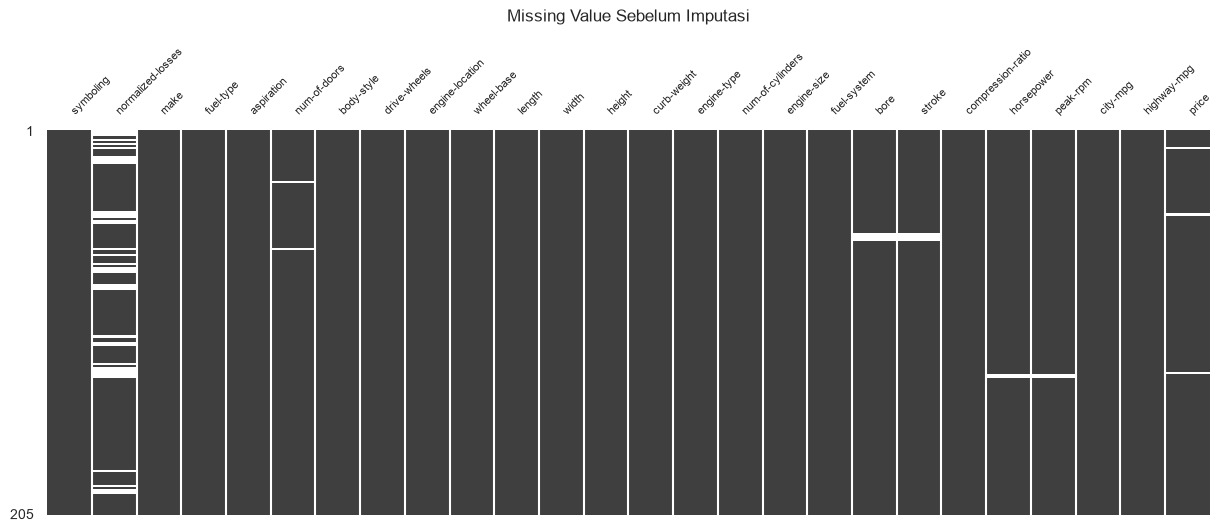

In [4]:
ax = missingno.matrix(df, figsize=(15, 5), fontsize=8, sparkline=False)
ax.set_title("Missing Value Sebelum Imputasi", pad=18)
save_figure(ax.get_figure(), "01_missing_sebelum.png")

In [5]:
numerical_cols_to_fill = ["normalized-losses", "bore", "stroke",
                          "horsepower", "peak-rpm", "price"]
imputation_records = []
for col in numerical_cols_to_fill:

    df[col] = pd.to_numeric(df[col], errors="raise").astype(float)
    mean_val = df[col].mean()
    if pd.isna(mean_val):
        raise ValueError(f"Mean tidak dapat dihitung untuk kolom {col}.")
    imputation_records.append({"kolom": col, "metode": "mean",
                               "nilai_pengisi": mean_val,
                               "jumlah_diisi": int(df[col].isna().sum())})
    df[col] = df[col].fillna(mean_val)

mode_val = df["num-of-doors"].mode().iloc[0]
imputation_records.append({"kolom": "num-of-doors", "metode": "modus",
                           "nilai_pengisi": mode_val,
                           "jumlah_diisi": int(df["num-of-doors"].isna().sum())})
df["num-of-doors"] = df["num-of-doors"].fillna(mode_val)
imputation_summary = pd.DataFrame(imputation_records)
missing_after = df.isnull().sum()
missing_summary = pd.DataFrame({"sebelum": missing_before, "sesudah": missing_after})
assert missing_after.sum() == 0, "Masih terdapat missing value setelah imputasi."
assert df.shape == df_raw.shape, "Imputasi tidak boleh menghapus baris atau kolom."
df_imputed = df.copy()
display(imputation_summary)
display(missing_summary.loc[missing_summary["sebelum"] > 0])
display(df.head())
print("Total missing value sesudah imputasi:", int(missing_after.sum()))

,kolom,metode,nilai_pengisi,jumlah_diisi
0,normalized-losses,mean,122.0,41
1,bore,mean,3.3298,4
2,stroke,mean,3.2554,4
3,horsepower,mean,104.2562,2
4,peak-rpm,mean,5125.3695,2
5,price,mean,13207.1294,4
6,num-of-doors,modus,four,2


,sebelum,sesudah
normalized-losses,41,0
num-of-doors,2,0
bore,4,0
stroke,4,0
horsepower,2,0
peak-rpm,2,0
price,4,0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


Total missing value sesudah imputasi: 0


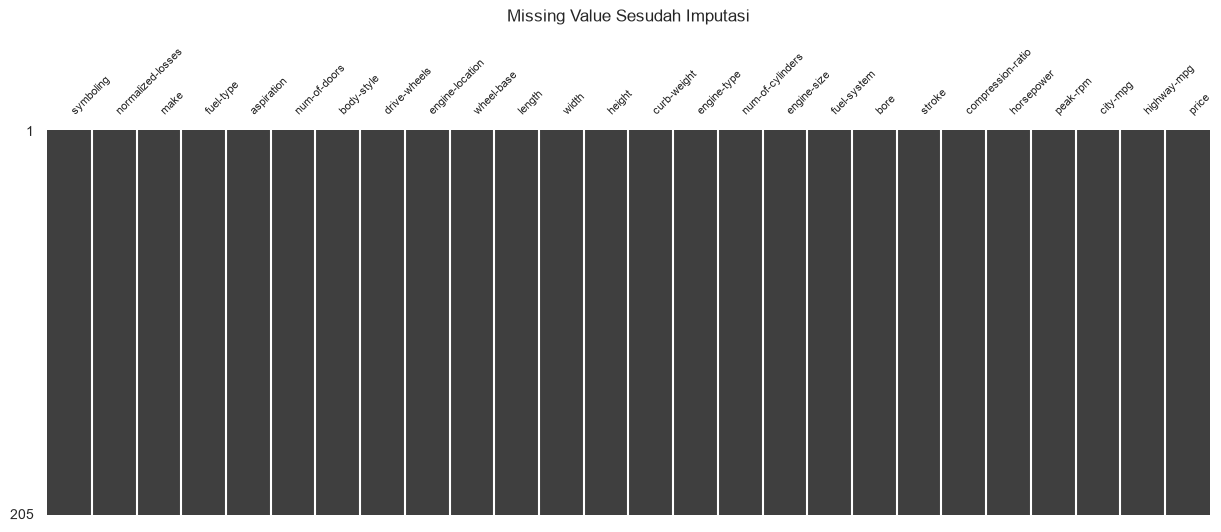

In [6]:
ax = missingno.matrix(df, figsize=(15, 5), fontsize=8, sparkline=False)
ax.set_title("Missing Value Sesudah Imputasi", pad=18)
save_figure(ax.get_figure(), "02_missing_sesudah.png")

# 2. Outlier

## A. Harga

Batas IQR: `Q1 - 1.5 × IQR` sampai `Q3 + 1.5 × IQR`.

In [7]:
Q1 = round(float(df["price"].quantile(0.25)), 12)
Q3 = round(float(df["price"].quantile(0.75)), 12)
IQR = round(Q3 - Q1, 12)
lower_bound = round(Q1 - 1.5 * IQR, 12)
upper_bound = round(Q3 + 1.5 * IQR, 12)
outliers = df.loc[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Price: Q1={Q1:.2f}; Q3={Q3:.2f}; IQR={IQR:.2f}")
print(f"Batas bawah={lower_bound:.2f}; batas atas={upper_bound:.2f}")
print("Jumlah outlier price sebelum clamping:", len(outliers))
display(outliers[["make", "body-style", "price"]])

Price: Q1=7788.00; Q3=16500.00; IQR=8712.00
Batas bawah=-5280.00; batas atas=29568.00
Jumlah outlier price sebelum clamping: 14


,make,body-style,price
15,bmw,sedan,30760.0
16,bmw,sedan,41315.0
17,bmw,sedan,36880.0
47,jaguar,sedan,32250.0
48,jaguar,sedan,35550.0
49,jaguar,sedan,36000.0
70,mercedes-benz,sedan,31600.0
71,mercedes-benz,sedan,34184.0
72,mercedes-benz,convertible,35056.0
73,mercedes-benz,sedan,40960.0


## B. Clamping

Nilai di luar batas IQR dibatasi dengan `clip`. Jumlah baris tetap sama.

In [8]:
def count_outliers(series, lower, upper):
    return int(((series < lower) | (series > upper)).sum())

numeric_cols = df.select_dtypes(include="number").columns.tolist()
df_before = df.copy()
outlier_records = []
for col in numeric_cols:
    q1 = round(float(df_before[col].quantile(0.25)), 12)
    q3 = round(float(df_before[col].quantile(0.75)), 12)
    iqr = round(q3 - q1, 12)

    lower = round(q1 - 1.5 * iqr, 12)
    upper = round(q3 + 1.5 * iqr, 12)
    before_count = count_outliers(df_before[col], lower, upper)
    df[col] = df_before[col].astype(float).clip(lower=lower, upper=upper)

    after_count = count_outliers(df[col], lower, upper)
    outlier_records.append({"kolom": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                            "batas_bawah": lower, "batas_atas": upper,
                            "outlier_sebelum": before_count, "outlier_sesudah": after_count,
                            "nilai_diubah": int((df[col] != df_before[col]).sum())})

outlier_summary = pd.DataFrame(outlier_records).set_index("kolom")
assert outlier_summary["outlier_sesudah"].sum() == 0
assert df.shape == df_before.shape
assert df.isna().sum().sum() == 0
display(outlier_summary.round(4))

,Q1,Q3,IQR,batas_bawah,batas_atas,outlier_sebelum,outlier_sesudah,nilai_diubah
kolom,,,,,,,,
symboling,0.00,2.00,2.00,-3.000,5.000,0,0,0
normalized-losses,101.00,137.00,36.00,47.000,191.000,8,0,8
wheel-base,94.50,102.40,7.90,82.650,114.250,3,0,3
length,166.30,183.10,16.80,141.100,208.300,0,0,0
width,64.10,66.90,2.80,59.900,71.100,8,0,8
height,52.00,55.50,3.50,46.750,60.750,0,0,0
curb-weight,2145.00,2935.00,790.00,960.000,4120.000,0,0,0
engine-size,97.00,141.00,44.00,31.000,207.000,10,0,10
bore,3.15,3.58,0.43,2.505,4.225,0,0,0


## C. Boxplot harga dan horsepower

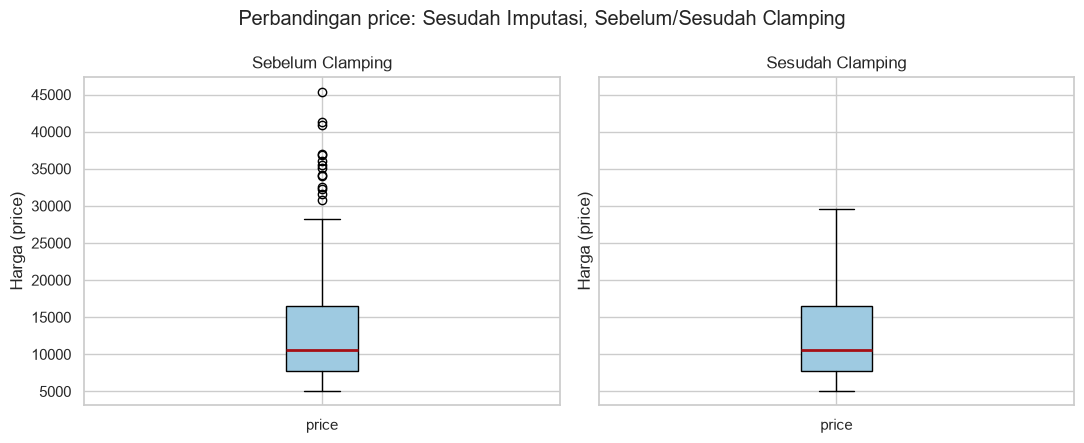

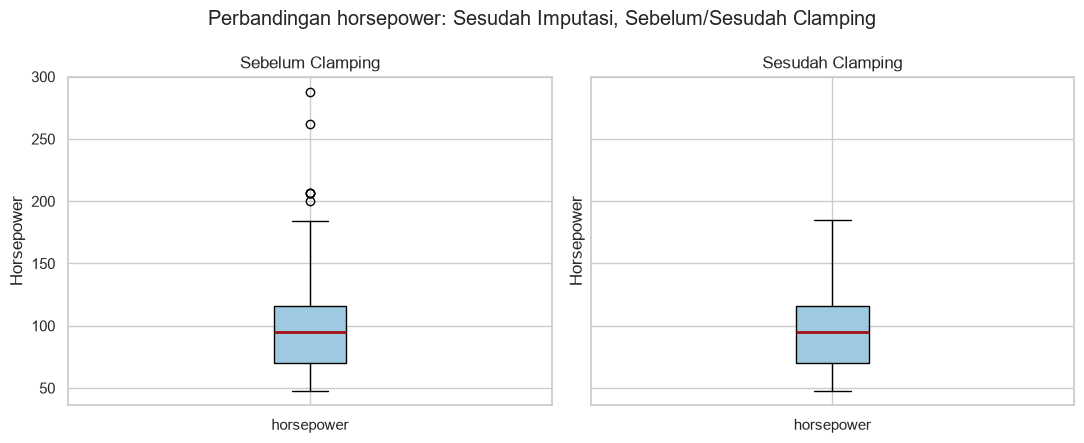

In [9]:
for feature in ["price", "horsepower"]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    for ax, values, title in zip(
        axes, [df_before[feature], df[feature]], ["Sebelum Clamping", "Sesudah Clamping"]
    ):
        ax.boxplot(values.to_numpy(), patch_artist=True,
                   boxprops={"facecolor": "#9ecae1"},
                   medianprops={"color": "#a50f15", "linewidth": 2})
        ax.set_title(title)
        ax.set_xticks([1], [feature])
        ax.set_ylabel("Harga (price)" if feature == "price" else "Horsepower")
    fig.suptitle(f"Perbandingan {feature}: Sesudah Imputasi, Sebelum/Sesudah Clamping")
    fig.tight_layout()
    save_figure(fig, f"03_boxplot_{feature}.png")

# 3. Pivot table

Pivot memakai data setelah clamping.

## A. Rata-rata harga menurut merek dan bentuk bodi

In [10]:
pivot_price = pd.pivot_table(df, values="price", index="make",
                            columns="body-style", aggfunc="mean", sort=True)
print("Rata-rata Harga menurut Merek dan Bentuk Bodi (Sesudah Clamping):")
display(pivot_price.round(2))

Rata-rata Harga menurut Merek dan Bentuk Bodi (Sesudah Clamping):


body-style,convertible,hardtop,hatchback,sedan,wagon
make,,,,,
alfa-romero,14997.5,NaN,16500.00,NaN,NaN
audi,NaN,NaN,13207.13,17647.00,18920.00
bmw,NaN,NaN,NaN,23587.38,NaN
chevrolet,NaN,NaN,5723.00,6575.00,NaN
dodge,NaN,NaN,7819.80,7619.67,8921.00
honda,NaN,NaN,7054.43,9945.00,7295.00
isuzu,NaN,NaN,11048.00,11066.42,NaN
jaguar,NaN,NaN,NaN,29568.00,NaN
mazda,NaN,NaN,10085.00,11464.14,NaN


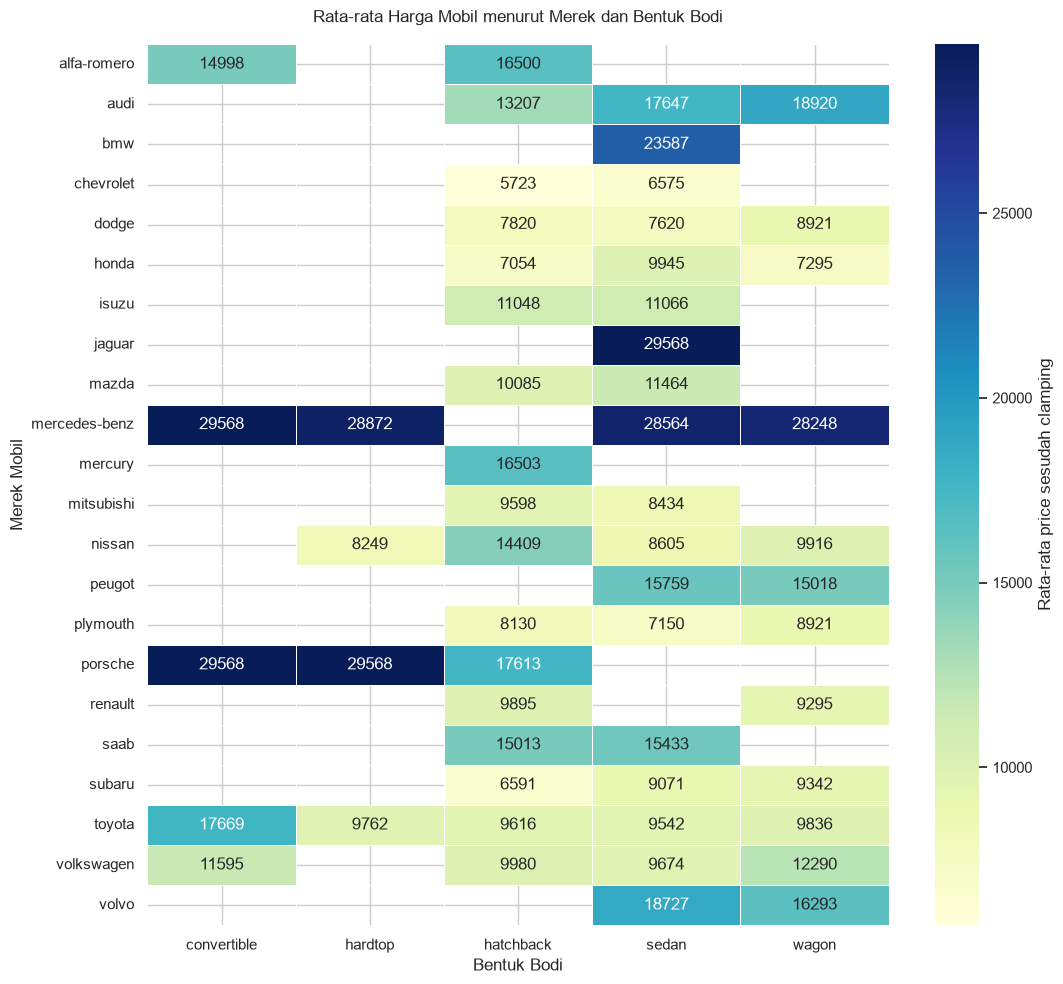

In [11]:
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(pivot_price, mask=pivot_price.isna(), annot=True, fmt=".0f",
            cmap="YlGnBu", linewidths=0.5,
            cbar_kws={"label": "Rata-rata price sesudah clamping"}, ax=ax)
ax.set_title("Rata-rata Harga Mobil menurut Merek dan Bentuk Bodi", pad=16)
ax.set_xlabel("Bentuk Bodi")
ax.set_ylabel("Merek Mobil")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "04_heatmap_harga.png")

## B. Rata-rata horsepower menurut bahan bakar dan aspiration

In [12]:
pivot_hp = pd.pivot_table(df, values="horsepower", index="fuel-type",
                         columns="aspiration", aggfunc="mean", sort=True)
print("Rata-rata Horsepower menurut Bahan Bakar dan Aspiration (Sesudah Clamping):")
display(pivot_hp.round(2))

Rata-rata Horsepower menurut Bahan Bakar dan Aspiration (Sesudah Clamping):


aspiration,std,turbo
fuel-type,,
diesel,58.14,98.62
gas,100.10,137.79


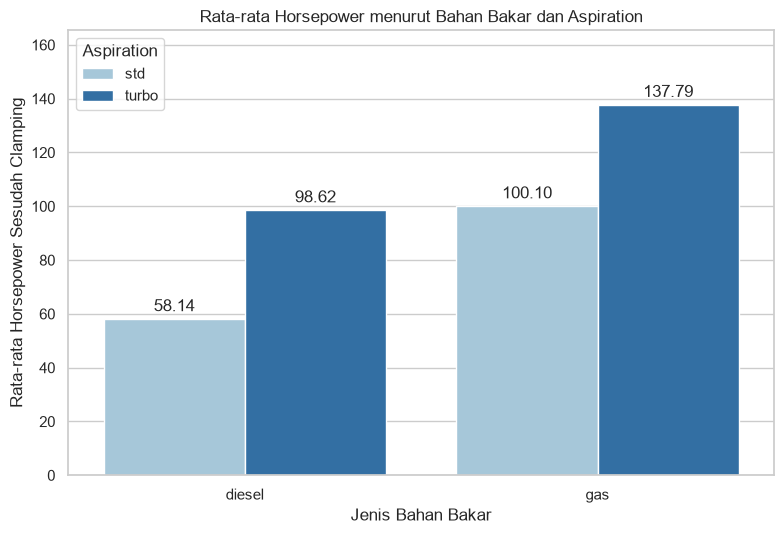

In [13]:
hp_long = pivot_hp.reset_index().melt(id_vars="fuel-type", var_name="aspiration",
                                     value_name="horsepower")
fig, ax = plt.subplots(figsize=(8, 5.5))

sns.barplot(data=hp_long, x="fuel-type", y="horsepower", hue="aspiration",
            order=["diesel", "gas"], hue_order=["std", "turbo"],
            errorbar=None, palette=["#9ecae1", "#2171b5"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
ax.set_ylim(0, hp_long["horsepower"].max() * 1.2)
ax.set_title("Rata-rata Horsepower menurut Bahan Bakar dan Aspiration")
ax.set_xlabel("Jenis Bahan Bakar")
ax.set_ylabel("Rata-rata Horsepower Sesudah Clamping")
ax.legend(title="Aspiration")
fig.tight_layout()
save_figure(fig, "05_barplot_horsepower.png")

## C. Jumlah mobil menurut pintu dan penggerak

In [14]:
pivot_distribution = pd.pivot_table(df, index="num-of-doors", columns="drive-wheels",
                                    aggfunc="size", fill_value=0, sort=True).astype(int)
assert int(pivot_distribution.to_numpy().sum()) == len(df)
print("Jumlah Mobil menurut Jumlah Pintu dan Jenis Penggerak:")
display(pivot_distribution)
print("Total mobil:", int(pivot_distribution.to_numpy().sum()))

Jumlah Mobil menurut Jumlah Pintu dan Jenis Penggerak:


drive-wheels,4wd,fwd,rwd
num-of-doors,,,
four,7,70,39
two,2,50,37


Total mobil: 205


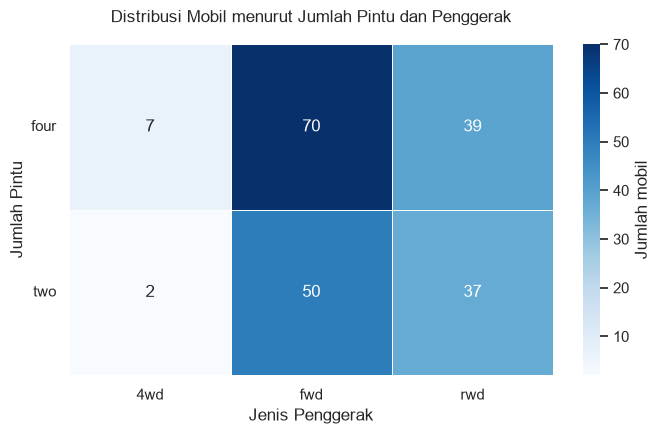

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_distribution, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Jumlah mobil"}, ax=ax)
ax.set_title("Distribusi Mobil menurut Jumlah Pintu dan Penggerak", pad=16)
ax.set_xlabel("Jenis Penggerak")
ax.set_ylabel("Jumlah Pintu")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "06_heatmap_distribusi.png")

# 4. Feature creation

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    float64
 1   normalized-losses  205 non-null    float64
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    float64
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    fl

## Binning horsepower

Horsepower dibagi menjadi tiga interval sama lebar: **Low**, **Medium**, dan **High**. Batasnya dihitung dari nilai minimum dan maksimum setelah clamping.

In [17]:
df["horsepower"].value_counts().sort_index()

horsepower
48.0     1
52.0     2
55.0     1
56.0     2
58.0     1
        ..
175.0    1
176.0    2
182.0    3
184.0    2
185.0    6
Name: count, Length: 57, dtype: int64

In [18]:
df["horsepower"].nunique()

57

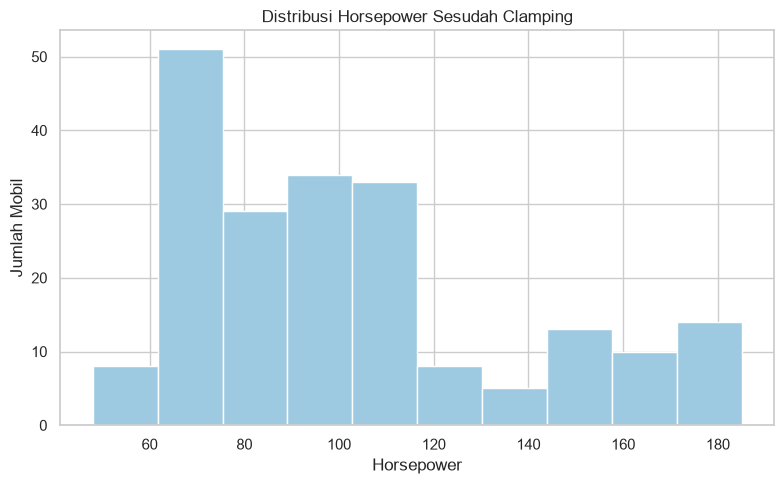

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["horsepower"], bins=10, color="#9ecae1", edgecolor="white")
ax.set_xlabel("Horsepower")
ax.set_ylabel("Jumlah Mobil")
ax.set_title("Distribusi Horsepower Sesudah Clamping")
fig.tight_layout()
save_figure(fig, "07_histogram_horsepower.png")

### Batas interval

In [20]:
bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
bins

array([ 48.        ,  93.66666667, 139.33333333, 185.        ])

In [21]:
group_names = ['Low', 'Medium', 'High']

### Kategori horsepower

In [22]:
df["horsepower-binned"] = pd.cut(
    df["horsepower"], bins=bins, labels=group_names, include_lowest=True
)
assert df["horsepower-binned"].notna().all()
df[["horsepower", "horsepower-binned"]].head(20)

,horsepower,horsepower-binned
0,111.0,Medium
1,111.0,Medium
2,154.0,High
3,102.0,Medium
4,115.0,Medium
5,110.0,Medium
6,110.0,Medium
7,110.0,Medium
8,140.0,High
9,160.0,High


In [23]:
bin_counts = df["horsepower-binned"].value_counts(sort=False).reindex(group_names)
bin_counts

horsepower-binned
Low       95
Medium    70
High      40
Name: count, dtype: int64

### Distribusi kategori

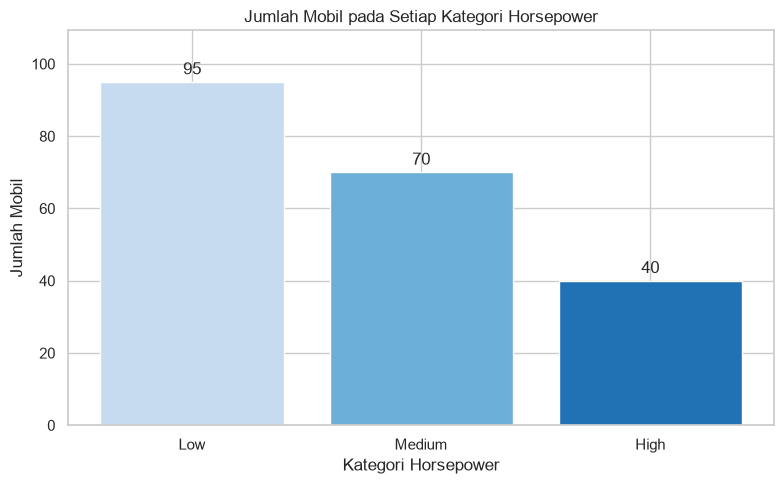

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(group_names, bin_counts.to_numpy(), color=["#c6dbef", "#6baed6", "#2171b5"])
ax.bar_label(bars, padding=3)
ax.set_ylim(0, bin_counts.max() * 1.15)
ax.set_xlabel("Kategori Horsepower")
ax.set_ylabel("Jumlah Mobil")
ax.set_title("Jumlah Mobil pada Setiap Kategori Horsepower")
fig.tight_layout()
save_figure(fig, "08_distribusi_kategori_horsepower.png")

### Histogram tiga bin

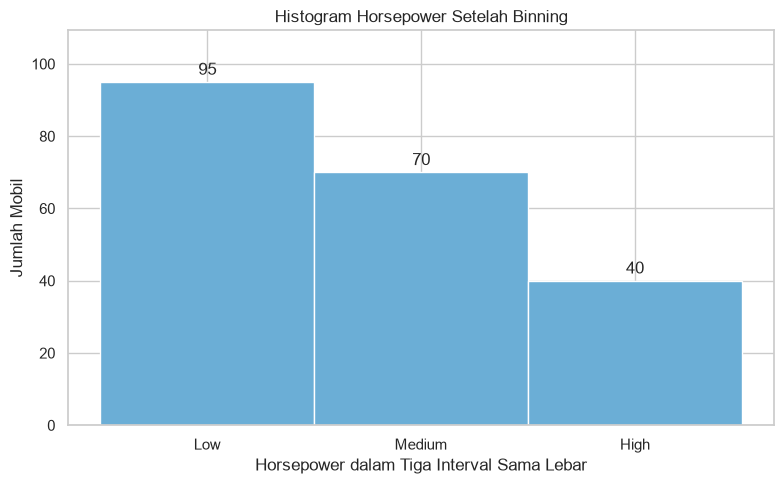

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
counts, edges, patches = ax.hist(
    df["horsepower"], bins=bins, color="#6baed6", edgecolor="white"
)
centres = (edges[:-1] + edges[1:]) / 2
ax.set_xticks(centres, group_names)
for centre, count in zip(centres, counts):
    ax.text(centre, count + 2, str(int(count)), ha="center")
ax.set_ylim(0, max(counts) * 1.15)
ax.set_xlabel("Horsepower dalam Tiga Interval Sama Lebar")
ax.set_ylabel("Jumlah Mobil")
ax.set_title("Histogram Horsepower Setelah Binning")
fig.tight_layout()
save_figure(fig, "09_histogram_tiga_bin.png")

# 5. Feature encoding

## A. One-hot encoding

Setiap kategori diubah menjadi kolom indikator bernilai 0 atau 1.

In [26]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'horsepower-binned'],
      dtype='str')

In [27]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"], dtype=int)
dummy_variable_1.head()

,diesel,gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [28]:
dummy_variable_1 = dummy_variable_1.rename(
    columns={"gas": "fuel-type-gas", "diesel": "fuel-type-diesel"}
)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [29]:
df = pd.concat([df, dummy_variable_1], axis=1).drop(columns="fuel-type")

In [30]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,horsepower-binned,fuel-type-diesel,fuel-type-gas
0,3.0,122.0,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,13495.0,Medium,0,1
1,3.0,122.0,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0,Medium,0,1
2,1.0,122.0,alfa-romero,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823.0,...,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0,High,0,1
3,2.0,164.0,audi,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337.0,...,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0,Medium,0,1
4,2.0,164.0,audi,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824.0,...,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0,Medium,0,1


### Soal 1 — Encoding aspiration

Buat indikator untuk kategori `std` dan `turbo`.

In [31]:
dummy_variable_2 = pd.get_dummies(df["aspiration"], dtype=int).rename(
    columns={"std": "aspiration-std", "turbo": "aspiration-turbo"}
)
dummy_variable_2.head()

,aspiration-std,aspiration-turbo
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


### Soal 2 — Gabungkan indikator

Gabungkan indikator aspiration, kemudian hapus kolom asalnya.

In [32]:
df = pd.concat([df, dummy_variable_2], axis=1).drop(columns="aspiration")

In [33]:
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,...,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3.0,122.0,alfa-romero,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,...,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,13495.0,Medium,0,1,1,0
1,3.0,122.0,alfa-romero,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,...,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0,Medium,0,1,1,0
2,1.0,122.0,alfa-romero,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823.0,ohcv,...,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0,High,0,1,1,0
3,2.0,164.0,audi,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337.0,ohc,...,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0,Medium,0,1,1,0
4,2.0,164.0,audi,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824.0,ohc,...,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0,Medium,0,1,1,0


In [34]:
df.select_dtypes(exclude="number").head()

,make,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
0,alfa-romero,two,convertible,rwd,front,dohc,four,mpfi,Medium
1,alfa-romero,two,convertible,rwd,front,dohc,four,mpfi,Medium
2,alfa-romero,two,hatchback,rwd,front,ohcv,six,mpfi,High
3,audi,four,sedan,fwd,front,ohc,four,mpfi,Medium
4,audi,four,sedan,4wd,front,ohc,five,mpfi,Medium


## B. Jumlah pintu dan silinder

Kategori yang menyatakan jumlah diubah menjadi angka sesuai nilainya.

In [35]:
df["num-of-doors"].value_counts().sort_index()

num-of-doors
four    116
two      89
Name: count, dtype: int64

In [36]:
door_mapping = {"two": 2, "four": 4}
df["num-of-doors"] = df["num-of-doors"].map(door_mapping).astype(int)
df["num-of-doors"].value_counts().sort_index()

num-of-doors
2     89
4    116
Name: count, dtype: int64

In [37]:
df["num-of-cylinders"].value_counts().sort_index()

num-of-cylinders
eight       5
five       11
four      159
six        24
three       1
twelve      1
two         4
Name: count, dtype: int64

In [38]:
cylinder_mapping = {
    "eight": 8, "five": 5, "four": 4, "six": 6,
    "three": 3, "twelve": 12, "two": 2
}
df["num-of-cylinders"] = df["num-of-cylinders"].map(cylinder_mapping).astype(int)

In [39]:
df["num-of-cylinders"].value_counts().sort_index()

num-of-cylinders
2       4
3       1
4     159
5      11
6      24
8       5
12      1
Name: count, dtype: int64

In [40]:
categorical_cols = [
    "make", "body-style", "drive-wheels", "engine-location", "engine-type", "fuel-system"
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)
df_encoded.head()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,...,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3.0,122.0,2,88.6,168.8,64.1,48.8,2548.0,4,130.0,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0,1,0,0
1,3.0,122.0,2,88.6,168.8,64.1,48.8,2548.0,4,130.0,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0,1,0,0
2,1.0,122.0,2,94.5,171.2,65.5,52.4,2823.0,6,152.0,2.68,3.47,9.0,...,0,0,0,1,0,0,0,0,0,0,1,0,0
3,2.0,164.0,4,99.8,176.6,66.2,54.3,2337.0,4,109.0,3.19,3.40,10.0,...,0,1,0,0,0,0,0,0,0,0,1,0,0
4,2.0,164.0,4,99.4,176.6,66.4,54.3,2824.0,5,136.0,3.19,3.40,8.0,...,0,1,0,0,0,0,0,0,0,0,1,0,0


In [41]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   symboling               205 non-null    float64 
 1   normalized-losses       205 non-null    float64 
 2   num-of-doors            205 non-null    int64   
 3   wheel-base              205 non-null    float64 
 4   length                  205 non-null    float64 
 5   width                   205 non-null    float64 
 6   height                  205 non-null    float64 
 7   curb-weight             205 non-null    float64 
 8   num-of-cylinders        205 non-null    int64   
 9   engine-size             205 non-null    float64 
 10  bore                    205 non-null    float64 
 11  stroke                  205 non-null    float64 
 12  compression-ratio       205 non-null    float64 
 13  horsepower              205 non-null    float64 
 14  peak-rpm                205 non-null 

## C. Soal 3 — Ordinal encoding

Kategori horsepower diberi kode `Low=0`, `Medium=1`, dan `High=2`.

In [42]:
ordinal_mapping = {"Low": 0, "Medium": 1, "High": 2}
df_encoded["horsepower-binned"] = (
    df_encoded["horsepower-binned"].map(ordinal_mapping).astype(int)
)
display(pd.DataFrame({"kategori": group_names, "kode": [ordinal_mapping[x] for x in group_names]}))
display(df_encoded[["horsepower", "horsepower-binned"]].head(20))

,kategori,kode
0,Low,0
1,Medium,1
2,High,2


,horsepower,horsepower-binned
0,111.0,1
1,111.0,1
2,154.0,2
3,102.0,1
4,115.0,1
5,110.0,1
6,110.0,1
7,110.0,1
8,140.0,2
9,160.0,2


# 6. Simpan data

In [43]:
assert len(df_encoded) == len(df_raw)
assert df_encoded.isna().sum().sum() == 0
assert df_encoded.columns.is_unique
assert df_encoded.select_dtypes(exclude="number").empty
df_encoded.to_csv("clean_df.csv", index=False)
print(f"Data akhir: {df_encoded.shape[0]} baris x {df_encoded.shape[1]} kolom.")
print("Data tersimpan sebagai clean_df.csv; gambar tersimpan di folder grafik.")

Data akhir: 205 baris x 70 kolom.
Data tersimpan sebagai clean_df.csv; gambar tersimpan di folder grafik.
